# Experiment 2: Data Preprocessing and Complete Exploratory Data Analysis (EDA)

## Dataset: Student Performance

### Aim
To understand, clean, explore, visualize, and preprocess a student-performance dataset so that it is ready for Machine Learning.

### Learning Objectives
After completing this experiment, students should be able to:

1. Load a CSV dataset using Pandas.
2. Inspect rows, columns, data types, and summary statistics.
3. Identify missing values and duplicate records.
4. Separate numerical, categorical, identifier, and target variables.
5. Perform univariate, bivariate, and multivariate EDA.
6. Interpret histograms, boxplots, bar charts, scatter plots, and correlation matrices.
7. Detect possible outliers.
8. Perform grouped analysis.
9. Handle missing numerical and categorical values.
10. Encode categorical features.
11. Split data into training and testing sets.
12. Standardize or normalize numerical variables.
13. Avoid common preprocessing mistakes such as data leakage.

---

## Dataset Columns

The supplied dataset contains the following fields:

- `student_id` – unique student identifier
- `name` – student name
- `gender` – gender category
- `age` – student age
- `class` – school class/grade
- `teacher_id` – teacher identifier
- `subject` – subject studied
- `test1_score` – score in Test 1
- `test2_score` – score in Test 2
- `final_exam_score` – score in final examination
- `final_grade_letter` – final letter grade
- `attendance_percentage` – attendance percentage
- `study_hours_per_week` – weekly study hours
- `assignments_submitted` – assignment submission percentage
- `pass_fail` – target variable: 1 = Pass, 0 = Fail

## 1. Import Required Libraries

We use:
- **Pandas** for data handling
- **NumPy** for numerical operations
- **Matplotlib** for visualization
- **Scikit-learn** for preprocessing and train/test splitting

In [63]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Make table output easier to read
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Dataset

Keep the CSV file in the same folder as this notebook.

The fallback path is included so that the notebook can also run in the current ChatGPT workspace.

In [64]:
DATA_PATH = "/kaggle/input/datasets/tahreemrashid/student-performance-dataset/student_performance.csv"


if not os.path.exists(DATA_PATH):
    DATA_PATH = "/kaggle/input/datasets/tahreemrashid/student-performance-dataset/student_performance.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset path:", DATA_PATH)

Dataset loaded successfully.
Dataset path: /kaggle/input/datasets/tahreemrashid/student-performance-dataset/student_performance.csv


# Part A — Initial Data Understanding

## 3. Display the First 10 Rows

`head()` allows us to visually inspect the structure and values in the dataset.

In [65]:
display(df.head(10))

,student_id,name,gender,age,class,teacher_id,subject,test1_score,test2_score,final_exam_score,final_grade_letter,attendance_percentage,study_hours_per_week,assignments_submitted,pass_fail
0,1,Carson Rivera,Female,14,9th,105,Math,23.5,40.5,50.5,F,70.2,3.1,56.7,0
1,2,Ashley Walters,Male,15,10th,107,Computer,77.7,80.6,82.3,B,85.3,6.9,81.0,1
2,3,Linda Robinson,Male,15,10th,103,English,75.0,73.4,64.5,C,83.1,4.3,66.3,1
3,4,Brandon James,Female,17,11th,117,Computer,46.7,53.1,51.2,F,74.1,0.4,44.9,0
4,5,Helen Grant,Female,16,10th,112,Science,38.0,57.3,47.6,F,73.8,1.4,49.9,0
5,6,Amy Marshall,Male,15,9th,111,Art,93.0,83.6,83.1,A,83.4,6.8,73.9,1
6,7,Michelle Watkins,Female,16,10th,109,Math,40.9,51.7,59.1,F,76.5,1.5,53.2,1
7,8,Sandra Mitchell,Female,15,10th,110,History,61.7,63.7,76.5,C,78.6,4.1,56.4,1
8,9,Sara Alvarez,Male,16,11th,105,Art,85.4,78.5,77.3,B,84.4,6.8,91.3,1
9,10,Matthew Robertson,Male,14,9th,109,History,44.8,55.3,60.8,F,79.8,2.2,54.5,1


## 4. Display the Last 5 Rows

In [66]:
display(df.tail())

,student_id,name,gender,age,class,teacher_id,subject,test1_score,test2_score,final_exam_score,final_grade_letter,attendance_percentage,study_hours_per_week,assignments_submitted,pass_fail
995,996,Cheryl Wells,Male,15,9th,109,History,78.7,76.2,72.0,B,80.5,4.4,60.6,1
996,997,Lauren Willis,Female,17,11th,117,Science,48.2,56.6,54.3,F,84.2,1.4,66.1,1
997,998,Jessica Perry,Male,15,10th,102,English,77.2,73.1,72.7,C,88.3,4.5,85.5,1
998,999,Rebecca Russell,Male,16,11th,115,Math,60.5,68.3,70.9,C,82.2,5.0,80.4,1
999,1000,Abigail Walters,Male,14,9th,103,Math,58.4,58.8,74.9,C,78.4,2.2,77.0,1


## 5. Find the Number of Rows and Columns

In [67]:
rows, columns = df.shape

print("Number of rows   :", rows)
print("Number of columns:", columns)
print("Dataset shape    :", df.shape)

Number of rows   : 1000
Number of columns: 15
Dataset shape    : (1000, 15)


## 6. Display Column Names

In [68]:
print("Columns in the dataset:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i:2d}. {column}")

Columns in the dataset:
 1. student_id
 2. name
 3. gender
 4. age
 5. class
 6. teacher_id
 7. subject
 8. test1_score
 9. test2_score
10. final_exam_score
11. final_grade_letter
12. attendance_percentage
13. study_hours_per_week
14. assignments_submitted
15. pass_fail


## 7. Examine Data Types

Understanding data types is necessary before preprocessing.

Typical types:
- `int64` / `float64` → numerical
- `object` → categorical/text

In [69]:
display(pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values
}))

,Column,Data Type
0,student_id,int64
1,name,object
2,gender,object
3,age,int64
4,class,object
5,teacher_id,int64
6,subject,object
7,test1_score,float64
8,test2_score,float64
9,final_exam_score,float64


## 8. Complete Dataset Information

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             1000 non-null   int64  
 1   name                   1000 non-null   object 
 2   gender                 1000 non-null   object 
 3   age                    1000 non-null   int64  
 4   class                  1000 non-null   object 
 5   teacher_id             1000 non-null   int64  
 6   subject                1000 non-null   object 
 7   test1_score            1000 non-null   float64
 8   test2_score            1000 non-null   float64
 9   final_exam_score       1000 non-null   float64
 10  final_grade_letter     1000 non-null   object 
 11  attendance_percentage  1000 non-null   float64
 12  study_hours_per_week   1000 non-null   float64
 13  assignments_submitted  1000 non-null   float64
 14  pass_fail              1000 non-null   int64  
dtypes: fl

## 9. Memory Usage

In [71]:
memory_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"Approximate memory used by dataset: {memory_mb:.3f} MB")

Approximate memory used by dataset: 0.338 MB


# Part B — Data Quality Assessment

## 10. Check Missing Values

We calculate both:
- number of missing values
- percentage of missing values

The supplied dataset currently has no missing values, but this is still an essential preprocessing step.

In [10]:
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing_count,
    "Missing Percentage": missing_percent.round(2)
})

display(missing_table)

,Missing Values,Missing Percentage
student_id,0,0.0
name,0,0.0
gender,0,0.0
age,0,0.0
class,0,0.0
teacher_id,0,0.0
subject,0,0.0
test1_score,0,0.0
test2_score,0,0.0
final_exam_score,0,0.0


## 11. Visualize Missing Values

A simple bar chart makes missingness easy to identify.

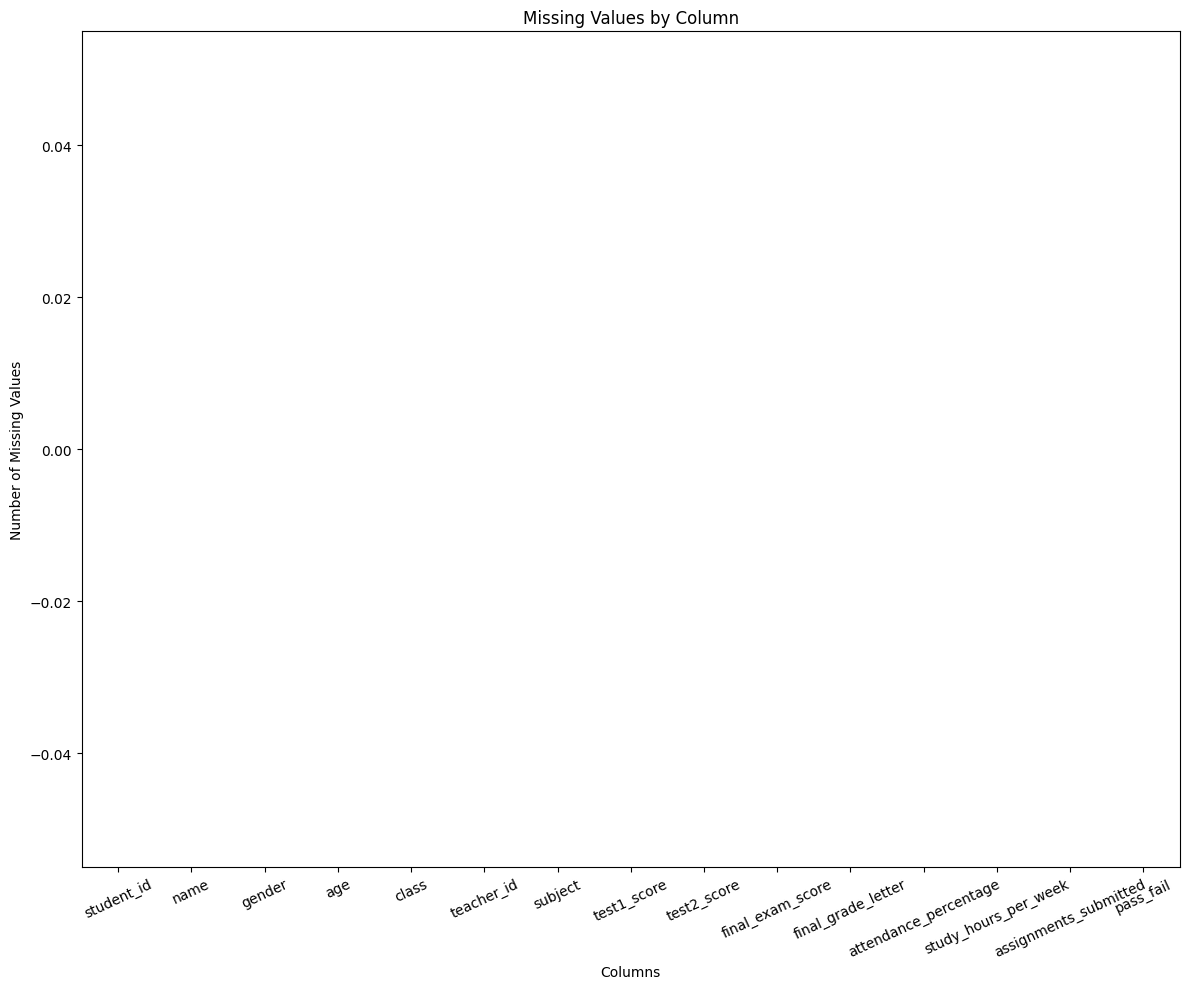

In [74]:
missing_count.plot(kind="bar", figsize=(12, 10))
plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## 12. Check Duplicate Rows

In [75]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)
print("Percentage of duplicate rows:",
      round((duplicate_count / len(df)) * 100, 2), "%")

Number of duplicate rows: 0
Percentage of duplicate rows: 0.0 %


## 13. Remove Duplicate Rows

This command is safe even when no duplicate rows exist.

In [13]:
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (1000, 15)


## 14. Check Number of Unique Values

This helps identify:
- identifiers
- binary variables
- categorical variables
- high-cardinality text fields

In [14]:
unique_table = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": [df[col].nunique() for col in df.columns]
}).sort_values("Unique Values")

display(unique_table)

,Column,Unique Values
2,gender,2
14,pass_fail,2
4,class,4
3,age,5
10,final_grade_letter,5
6,subject,6
5,teacher_id,20
12,study_hours_per_week,105
11,attendance_percentage,291
13,assignments_submitted,458


# Part C — Descriptive Statistics

## 15. Summary Statistics for Numerical Variables

`describe()` returns:
- count
- mean
- standard deviation
- minimum
- quartiles
- maximum

In [15]:
numerical_summary = df.describe().T
display(numerical_summary.round(2))

,count,mean,std,min,25%,50%,75%,max
student_id,1000.0,500.50,288.82,1.0,250.75,500.5,750.25,1000.0
age,1000.0,15.88,1.22,14.0,15.00,16.0,17.00,18.0
teacher_id,1000.0,110.59,5.72,101.0,106.00,110.0,115.25,120.0
test1_score,1000.0,63.94,14.76,17.1,53.80,64.0,73.90,100.0
test2_score,1000.0,66.13,14.95,24.4,56.38,65.7,76.93,100.0
final_exam_score,1000.0,68.41,15.50,25.0,57.40,68.0,79.32,100.0
attendance_percentage,1000.0,82.14,6.90,63.9,77.20,82.1,86.80,100.0
study_hours_per_week,1000.0,4.26,2.29,0.0,2.60,4.1,5.82,12.0
assignments_submitted,1000.0,68.98,14.09,22.8,59.28,68.5,79.10,100.0
pass_fail,1000.0,0.83,0.38,0.0,1.00,1.0,1.00,1.0


## 16. Summary Statistics for Categorical Variables

In [16]:
categorical_summary = df.describe(include=["object"]).T
display(categorical_summary)

,count,unique,top,freq
name,1000,1000,Abigail Walters,1
gender,1000,2,Male,529
class,1000,4,9th,283
subject,1000,6,Math,225
final_grade_letter,1000,5,C,258


## 17. Identify Numerical and Categorical Columns

In [17]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['student_id', 'age', 'teacher_id', 'test1_score', 'test2_score', 'final_exam_score', 'attendance_percentage', 'study_hours_per_week', 'assignments_submitted', 'pass_fail']

Categorical columns:
['name', 'gender', 'class', 'subject', 'final_grade_letter']


### Important Observation

Some numerical-looking columns are actually identifiers:

- `student_id`
- `teacher_id`

They should generally **not** be treated as continuous measurements during EDA or model scaling.

Likewise, `name` is an identifier-like text field and should normally be excluded from a predictive model.

In [18]:
identifier_columns = ["student_id", "name", "teacher_id"]
target_column = "pass_fail"

analysis_numeric_columns = [
    col for col in numerical_columns
    if col not in ["student_id", "teacher_id", "pass_fail"]
]

print("Numerical variables used for EDA:")
print(analysis_numeric_columns)

Numerical variables used for EDA:
['age', 'test1_score', 'test2_score', 'final_exam_score', 'attendance_percentage', 'study_hours_per_week', 'assignments_submitted']


# Part D — Univariate EDA

Univariate analysis studies **one variable at a time**.

## 18. Frequency Tables for Categorical Variables

In [19]:
eda_categorical_columns = [
    "gender",
    "class",
    "subject",
    "final_grade_letter",
    "pass_fail"
]

for column in eda_categorical_columns:
    print("\n" + "=" * 60)
    print(f"Frequency distribution of: {column}")
    print("=" * 60)

    frequency = df[column].value_counts(dropna=False)
    percentage = df[column].value_counts(
        dropna=False, normalize=True
    ).mul(100).round(2)

    table = pd.DataFrame({
        "Count": frequency,
        "Percentage": percentage
    })

    display(table)


Frequency distribution of: gender


,Count,Percentage
gender,,
Male,529,52.9
Female,471,47.1



Frequency distribution of: class


,Count,Percentage
class,,
9th,283,28.3
12th,251,25.1
11th,247,24.7
10th,219,21.9



Frequency distribution of: subject


,Count,Percentage
subject,,
Math,225,22.5
Computer,193,19.3
English,193,19.3
Science,187,18.7
History,153,15.3
Art,49,4.9



Frequency distribution of: final_grade_letter


,Count,Percentage
final_grade_letter,,
C,258,25.8
D,242,24.2
F,217,21.7
B,185,18.5
A,98,9.8



Frequency distribution of: pass_fail


,Count,Percentage
pass_fail,,
1,830,83.0
0,170,17.0


## 19. Histograms of Numerical Variables

Histograms show:
- distribution shape
- concentration of observations
- skewness
- possible unusual values

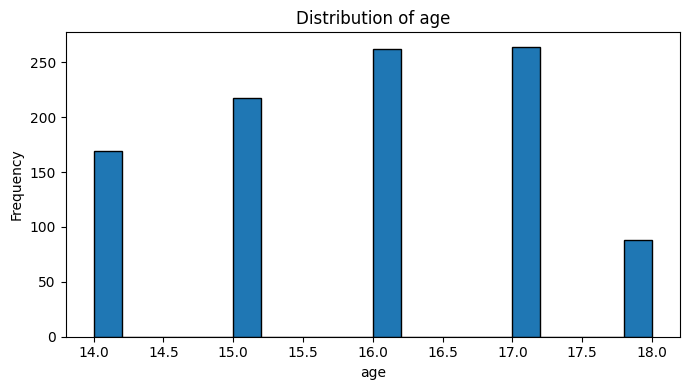

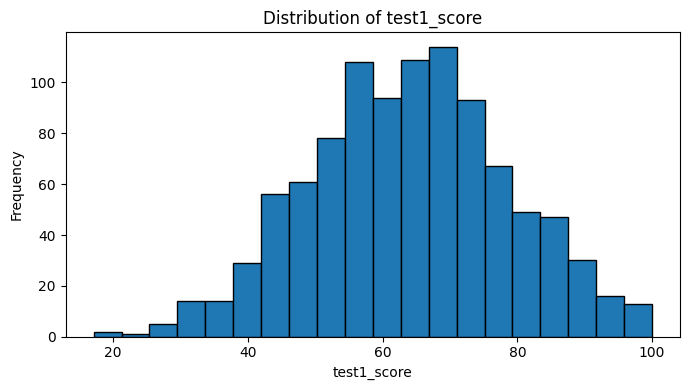

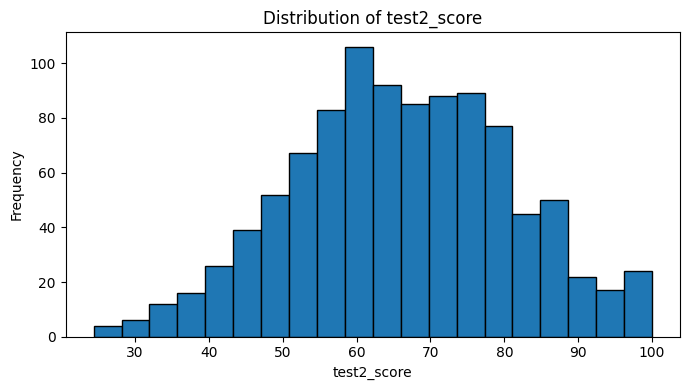

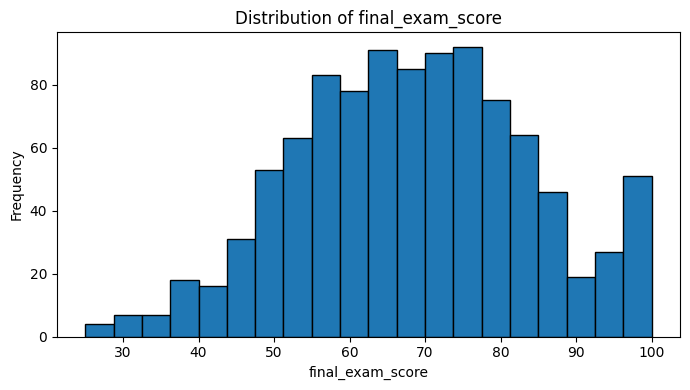

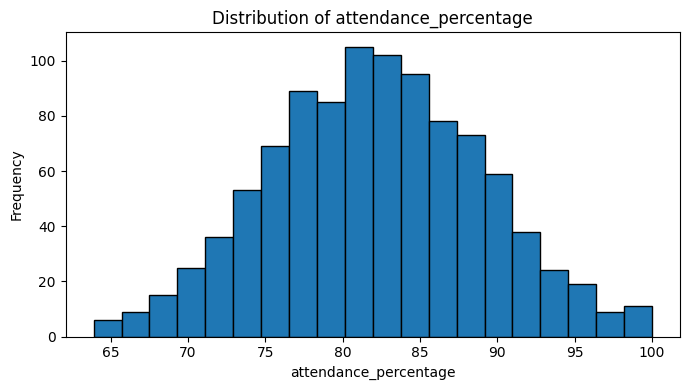

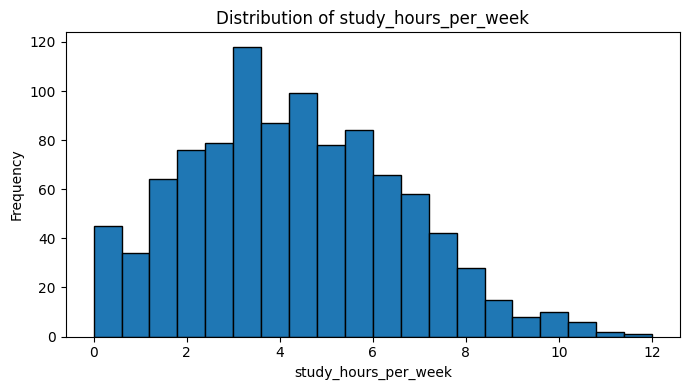

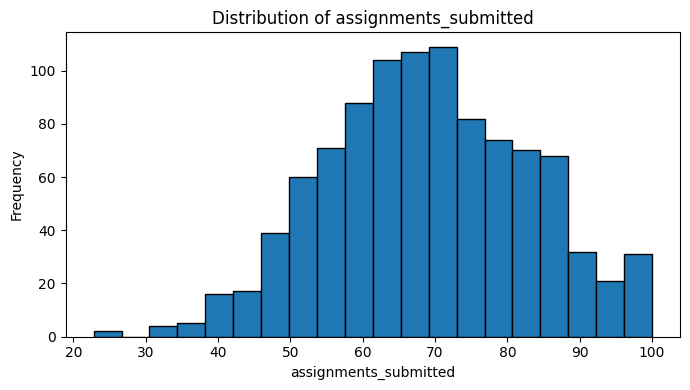

In [20]:
for column in analysis_numeric_columns:
    plt.figure(figsize=(7, 4))
    plt.hist(df[column].dropna(), bins=20, edgecolor="black")
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## 20. Boxplots of Numerical Variables

Boxplots are useful for:
- median
- spread
- interquartile range
- possible outliers

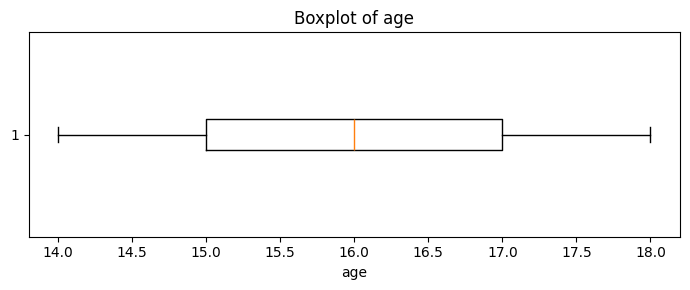

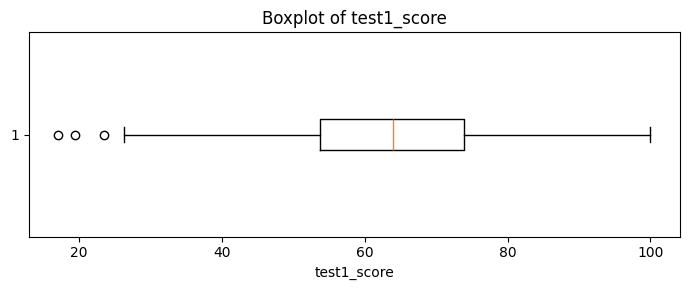

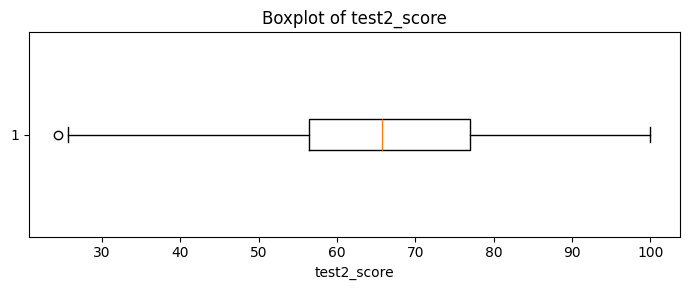

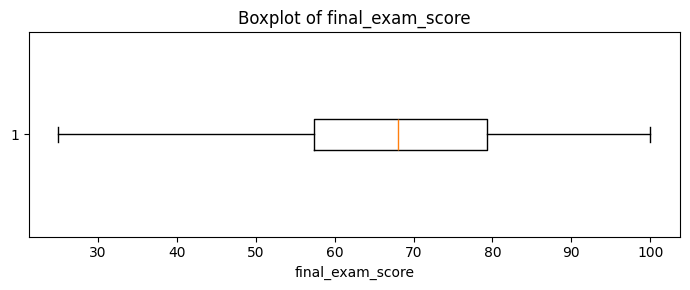

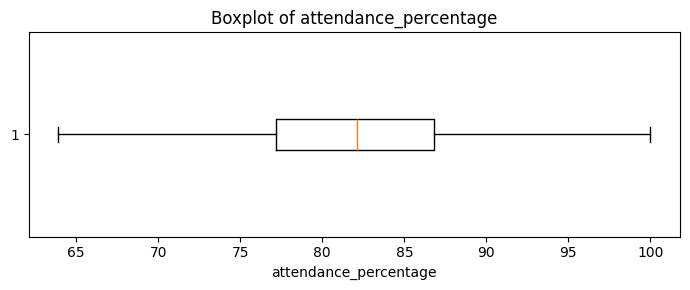

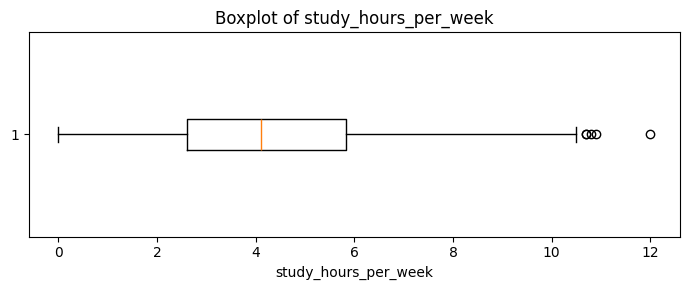

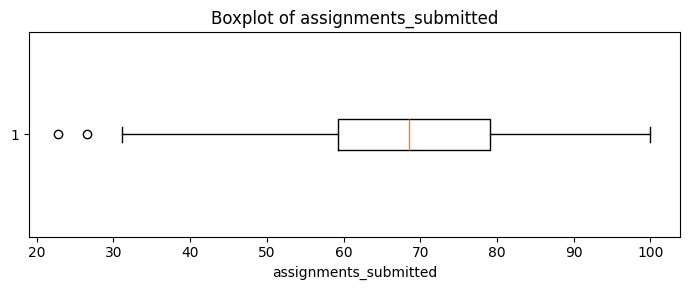

In [21]:
for column in analysis_numeric_columns:
    plt.figure(figsize=(7, 3))
    plt.boxplot(df[column].dropna(), vert=False)
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.tight_layout()
    plt.show()

## 21. Bar Charts for Categorical Variables

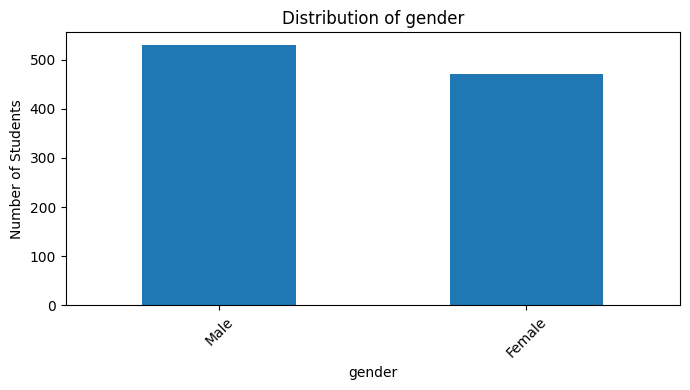

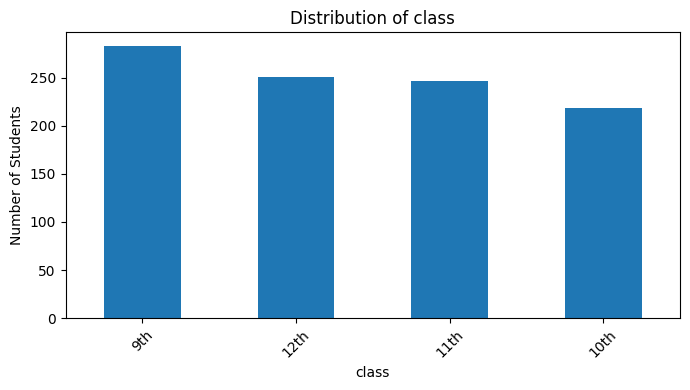

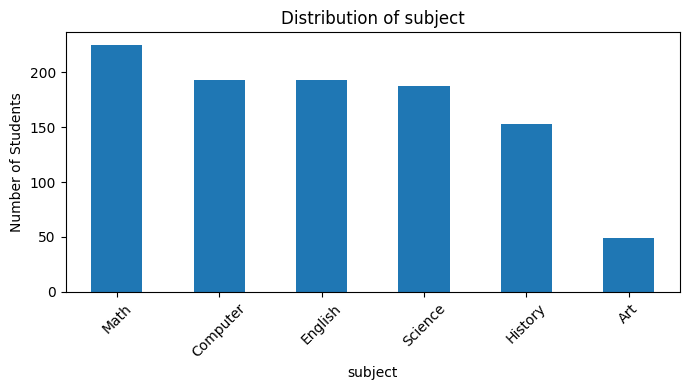

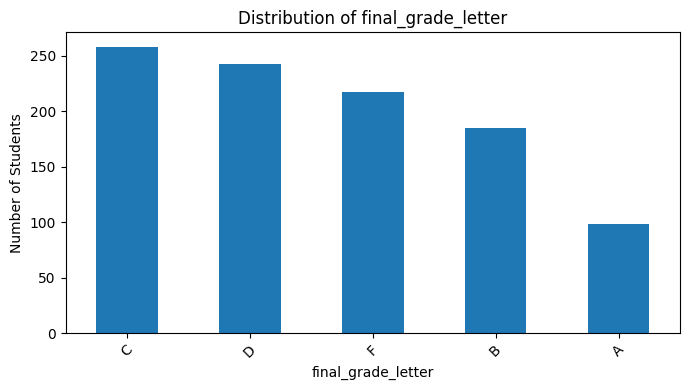

In [22]:
for column in ["gender", "class", "subject", "final_grade_letter"]:
    counts = df[column].value_counts()

    plt.figure(figsize=(7, 4))
    counts.plot(kind="bar")
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Students")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 22. Pass/Fail Distribution

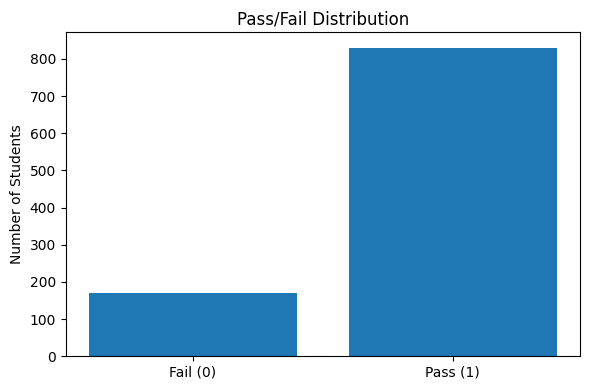

Pass/Fail counts:


pass_fail
Pass    830
Fail    170
Name: count, dtype: int64

In [23]:
pass_fail_counts = df["pass_fail"].value_counts().sort_index()

labels = ["Fail (0)", "Pass (1)"]

plt.figure(figsize=(6, 4))
plt.bar(labels, [
    pass_fail_counts.get(0, 0),
    pass_fail_counts.get(1, 0)
])
plt.title("Pass/Fail Distribution")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

print("Pass/Fail counts:")
display(df["pass_fail"].value_counts().rename(index={0: "Fail", 1: "Pass"}))

## 23. Calculate Pass Percentage

In [25]:
pass_percentage = df["pass_fail"].mean() * 100
fail_percentage = 100 - pass_percentage

print(f"Pass percentage: {pass_percentage:.2f}%")
print(f"Fail percentage: {fail_percentage:.2f}%")

Pass percentage: 83.00%
Fail percentage: 17.00%


# Part E — Outlier Analysis

## 24. Detect Possible Outliers Using the IQR Method

The Interquartile Range is:

`IQR = Q3 - Q1`

A value is often considered a possible outlier when:

- value < Q1 − 1.5 × IQR
- value > Q3 + 1.5 × IQR

These values should **not automatically be deleted**. They should first be investigated.

In [27]:
outlier_report = []

for column in analysis_numeric_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_report.append({
        "Feature": column,
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "IQR": round(iqr, 2),
        "Lower Bound": round(lower_bound, 2),
        "Upper Bound": round(upper_bound, 2),
        "Possible Outliers": len(outliers)
    })

outlier_report_df = pd.DataFrame(outlier_report)
display(outlier_report_df)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Possible Outliers
0,age,15.00,17.00,2.00,12.00,20.00,0
1,test1_score,53.80,73.90,20.10,23.65,104.05,3
2,test2_score,56.38,76.93,20.55,25.55,107.75,1
3,final_exam_score,57.40,79.32,21.93,24.51,112.21,0
4,attendance_percentage,77.20,86.80,9.60,62.80,101.20,0
5,study_hours_per_week,2.60,5.82,3.22,-2.24,10.66,5
6,assignments_submitted,59.28,79.10,19.82,29.54,108.84,2


# Part F — Bivariate EDA

Bivariate analysis studies the relationship between **two variables**.

## 25. Test 1 Score vs Test 2 Score

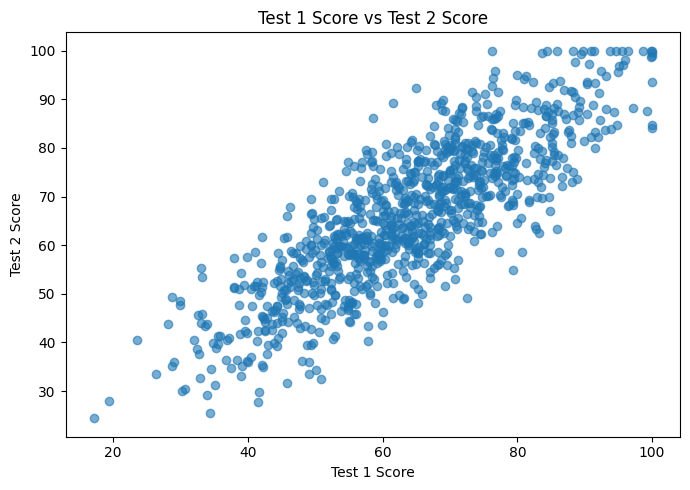

In [28]:
plt.figure(figsize=(7, 5))
plt.scatter(df["test1_score"], df["test2_score"], alpha=0.6)
plt.title("Test 1 Score vs Test 2 Score")
plt.xlabel("Test 1 Score")
plt.ylabel("Test 2 Score")
plt.tight_layout()
plt.show()

## 26. Study Hours vs Final Exam Score

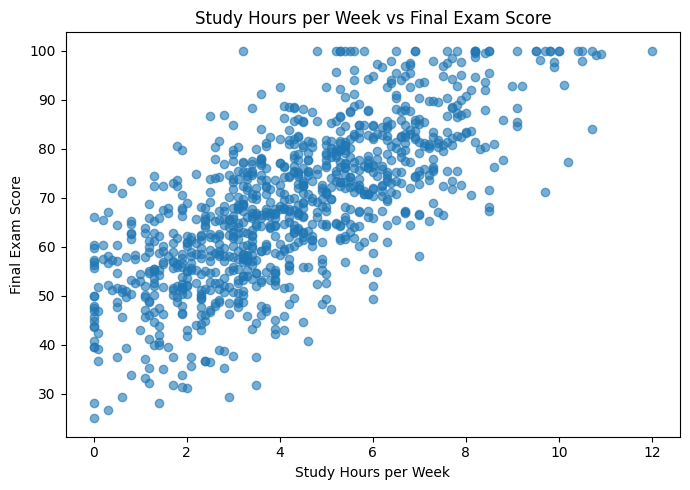

In [29]:
plt.figure(figsize=(7, 5))
plt.scatter(
    df["study_hours_per_week"],
    df["final_exam_score"],
    alpha=0.6
)
plt.title("Study Hours per Week vs Final Exam Score")
plt.xlabel("Study Hours per Week")
plt.ylabel("Final Exam Score")
plt.tight_layout()
plt.show()

## 27. Attendance vs Final Exam Score

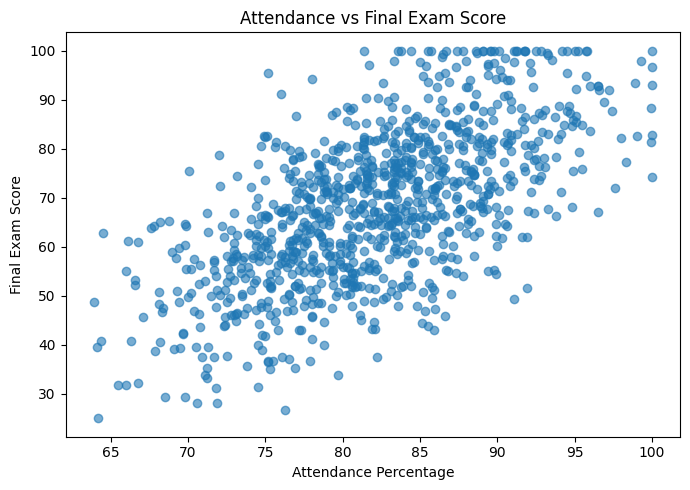

In [30]:
plt.figure(figsize=(7, 5))
plt.scatter(
    df["attendance_percentage"],
    df["final_exam_score"],
    alpha=0.6
)
plt.title("Attendance vs Final Exam Score")
plt.xlabel("Attendance Percentage")
plt.ylabel("Final Exam Score")
plt.tight_layout()
plt.show()

## 28. Assignments Submitted vs Final Exam Score

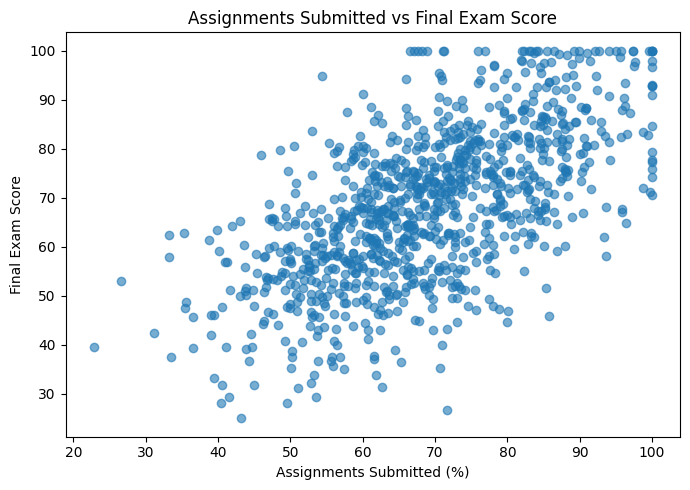

In [31]:
plt.figure(figsize=(7, 5))
plt.scatter(
    df["assignments_submitted"],
    df["final_exam_score"],
    alpha=0.6
)
plt.title("Assignments Submitted vs Final Exam Score")
plt.xlabel("Assignments Submitted (%)")
plt.ylabel("Final Exam Score")
plt.tight_layout()
plt.show()

## 29. Average Scores by Gender

In [33]:
gender_scores = df.groupby("gender")[
    ["test1_score", "test2_score", "final_exam_score"]
].mean().round(2)

display(gender_scores)

,test1_score,test2_score,final_exam_score
gender,,,
Female,64.37,66.26,68.82
Male,63.56,66.01,68.04


## 30. Average Final Exam Score by Subject

subject
Computer    70.64
Art         70.59
English     70.50
History     68.00
Science     66.64
Math        65.98
Name: final_exam_score, dtype: float64

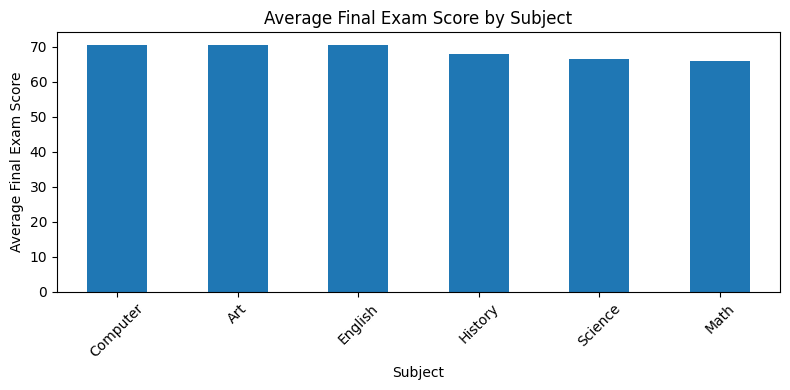

In [34]:
subject_exam = (
    df.groupby("subject")["final_exam_score"]
      .mean()
      .sort_values(ascending=False)
)

display(subject_exam.round(2))

plt.figure(figsize=(8, 4))
subject_exam.plot(kind="bar")
plt.title("Average Final Exam Score by Subject")
plt.xlabel("Subject")
plt.ylabel("Average Final Exam Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 31. Average Final Exam Score by Class

class
9th     67.33
10th    67.92
11th    69.95
12th    68.54
Name: final_exam_score, dtype: float64

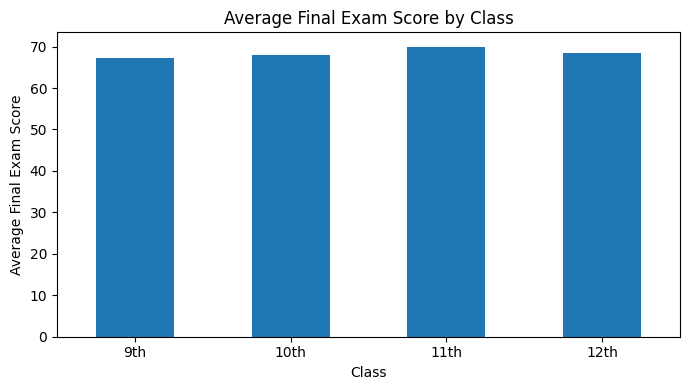

In [35]:
class_order = ["9th", "10th", "11th", "12th"]

class_exam = (
    df.groupby("class")["final_exam_score"]
      .mean()
      .reindex(class_order)
)

display(class_exam.round(2))

plt.figure(figsize=(7, 4))
class_exam.plot(kind="bar")
plt.title("Average Final Exam Score by Class")
plt.xlabel("Class")
plt.ylabel("Average Final Exam Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 32. Pass Rate by Gender

gender
Female    83.65
Male      82.42
Name: Pass Rate (%), dtype: float64

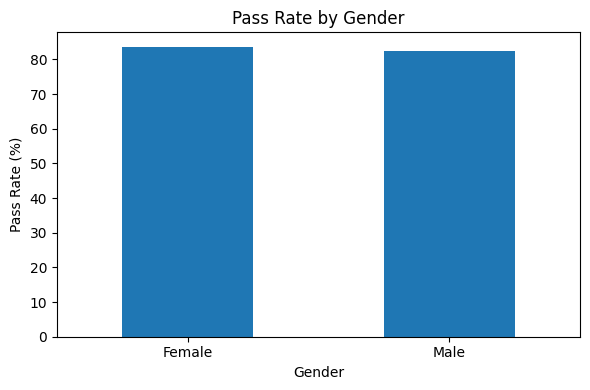

In [36]:
gender_pass_rate = (
    df.groupby("gender")["pass_fail"]
      .mean()
      .mul(100)
      .round(2)
)

display(gender_pass_rate.rename("Pass Rate (%)"))

plt.figure(figsize=(6, 4))
gender_pass_rate.plot(kind="bar")
plt.title("Pass Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Pass Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 33. Pass Rate by Subject

subject
Computer    84.46
History     84.31
Math        84.00
English     83.94
Art         79.59
Science     79.14
Name: Pass Rate (%), dtype: float64

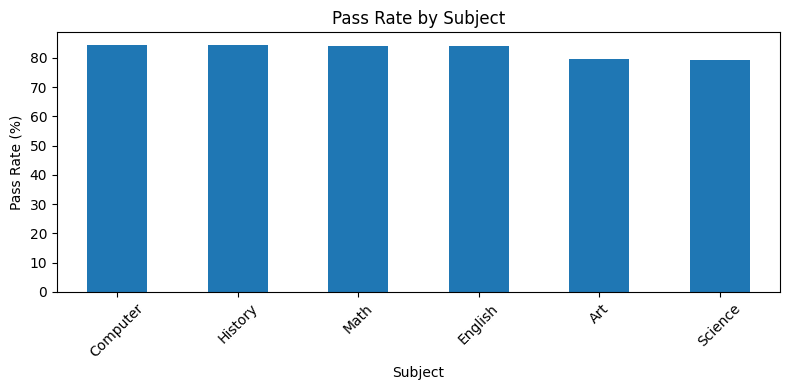

In [37]:
subject_pass_rate = (
    df.groupby("subject")["pass_fail"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

display(subject_pass_rate.round(2).rename("Pass Rate (%)"))

plt.figure(figsize=(8, 4))
subject_pass_rate.plot(kind="bar")
plt.title("Pass Rate by Subject")
plt.xlabel("Subject")
plt.ylabel("Pass Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 34. Pass Rate by Class

class
9th     80.57
10th    82.65
11th    83.81
12th    85.26
Name: Pass Rate (%), dtype: float64

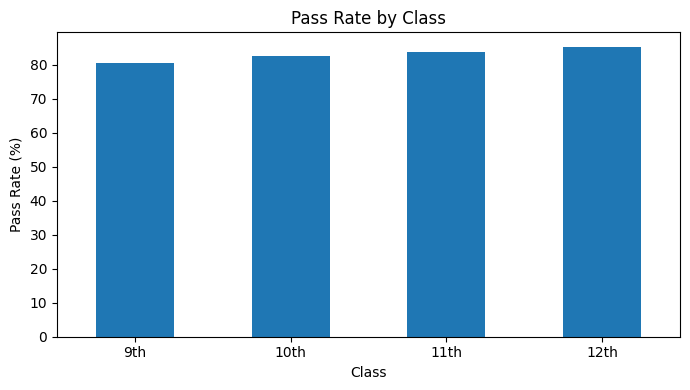

In [38]:
class_pass_rate = (
    df.groupby("class")["pass_fail"]
      .mean()
      .mul(100)
      .reindex(class_order)
)

display(class_pass_rate.round(2).rename("Pass Rate (%)"))

plt.figure(figsize=(7, 4))
class_pass_rate.plot(kind="bar")
plt.title("Pass Rate by Class")
plt.xlabel("Class")
plt.ylabel("Pass Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 35. Mean Numerical Values for Pass vs Fail Students

In [39]:
pass_fail_comparison = (
    df.groupby("pass_fail")[analysis_numeric_columns]
      .mean()
      .T
      .rename(columns={0: "Fail", 1: "Pass"})
)

display(pass_fail_comparison.round(2))

pass_fail,Fail,Pass
age,15.80,15.90
test1_score,45.17,67.79
test2_score,47.31,69.98
final_exam_score,49.29,72.33
attendance_percentage,73.96,83.82
study_hours_per_week,1.93,4.73
assignments_submitted,51.25,72.61


# Part G — Multivariate EDA

## 36. Correlation Matrix

Correlation values range approximately from:

- `+1` → strong positive relationship
- `0` → weak/no linear relationship
- `-1` → strong negative relationship

In [40]:
correlation_columns = analysis_numeric_columns + ["pass_fail"]

correlation_matrix = df[correlation_columns].corr()

display(correlation_matrix.round(3))

,age,test1_score,test2_score,final_exam_score,attendance_percentage,study_hours_per_week,assignments_submitted,pass_fail
age,1.000,0.009,0.032,0.034,0.039,0.029,0.000,0.031
test1_score,0.009,1.000,0.831,0.792,0.670,0.761,0.641,0.576
test2_score,0.032,0.831,1.000,0.783,0.664,0.769,0.643,0.570
final_exam_score,0.034,0.792,0.783,1.000,0.634,0.726,0.631,0.559
attendance_percentage,0.039,0.670,0.664,0.634,1.000,0.646,0.786,0.537
study_hours_per_week,0.029,0.761,0.769,0.726,0.646,1.000,0.701,0.460
assignments_submitted,0.000,0.641,0.643,0.631,0.786,0.701,1.000,0.570
pass_fail,0.031,0.576,0.570,0.559,0.537,0.460,0.570,1.000


## 37. Correlation Heatmap Using Matplotlib

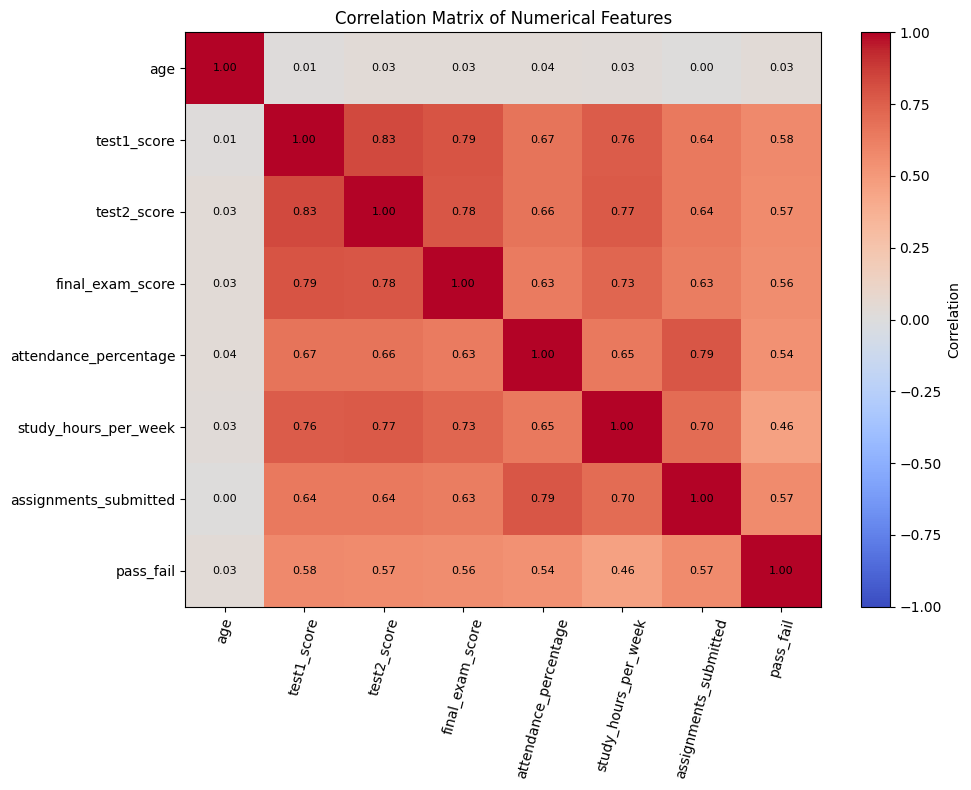

In [41]:
plt.figure(figsize=(10, 8))

image = plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="auto"
)

plt.colorbar(image, label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=75
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

# Add correlation values inside cells
for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

## 38. Find Features Most Correlated with Pass/Fail

This does not prove causation. It only shows linear association.

In [42]:
target_correlations = (
    correlation_matrix["pass_fail"]
    .drop("pass_fail")
    .sort_values(key=abs, ascending=False)
)

display(target_correlations.to_frame("Correlation with pass_fail"))

,Correlation with pass_fail
test1_score,0.575835
test2_score,0.570083
assignments_submitted,0.569720
final_exam_score,0.558734
attendance_percentage,0.536972
study_hours_per_week,0.460123
age,0.031454


# Part H — Additional Useful EDA

## 39. Grade Distribution by Subject

In [43]:
grade_subject_table = pd.crosstab(
    df["subject"],
    df["final_grade_letter"]
)

display(grade_subject_table)

final_grade_letter,A,B,C,D,F
subject,,,,,
Art,8,10,13,7,11
Computer,25,42,52,35,39
English,29,41,40,49,34
History,16,25,39,31,42
Math,8,36,67,65,49
Science,12,31,47,55,42


## 40. Pass/Fail Cross-tabulation by Gender

In [44]:
gender_pass_table = pd.crosstab(
    df["gender"],
    df["pass_fail"],
    margins=True
)

gender_pass_table = gender_pass_table.rename(
    columns={0: "Fail", 1: "Pass"}
)

display(gender_pass_table)

pass_fail,Fail,Pass,All
gender,,,
Female,77,394,471
Male,93,436,529
All,170,830,1000


## 41. Pass/Fail Cross-tabulation by Class

In [45]:
class_pass_table = pd.crosstab(
    df["class"],
    df["pass_fail"]
).reindex(class_order)

class_pass_table = class_pass_table.rename(
    columns={0: "Fail", 1: "Pass"}
)

display(class_pass_table)

pass_fail,Fail,Pass
class,,
9th,55,228
10th,38,181
11th,40,207
12th,37,214


## 42. Create a Combined Average Score for EDA

This is an **EDA-only derived variable** representing the simple mean of Test 1, Test 2, and Final Exam scores.

It is useful for descriptive analysis, but whether it should be used in a predictive model depends on the prediction problem.

In [46]:
df_eda = df.copy()

df_eda["average_score"] = df_eda[
    ["test1_score", "test2_score", "final_exam_score"]
].mean(axis=1)

display(
    df_eda[
        ["test1_score", "test2_score", "final_exam_score", "average_score"]
    ].head()
)

,test1_score,test2_score,final_exam_score,average_score
0,23.5,40.5,50.5,38.166667
1,77.7,80.6,82.3,80.200000
2,75.0,73.4,64.5,70.966667
3,46.7,53.1,51.2,50.333333
4,38.0,57.3,47.6,47.633333


## 43. Average Score Distribution

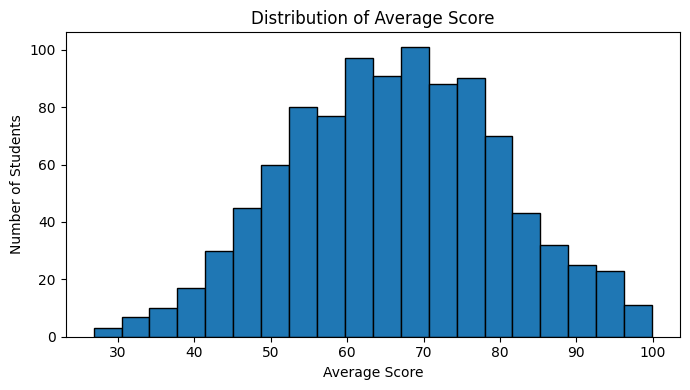

In [47]:
plt.figure(figsize=(7, 4))
plt.hist(df_eda["average_score"], bins=20, edgecolor="black")
plt.title("Distribution of Average Score")
plt.xlabel("Average Score")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

# Part I — Data Preprocessing for Machine Learning

## 44. Choose the Prediction Target

For this experiment, we use:

`pass_fail`

where:
- `0` = Fail
- `1` = Pass

### Important: Identifier Removal

The following should normally not be used directly as predictive features:

- `student_id`
- `name`
- `teacher_id`

They identify people/entities rather than measuring student performance.

### Important: Potential Target Leakage

`final_grade_letter` may be directly derived from the student's final performance and therefore can leak information about `pass_fail`.

If the aim is to predict pass/fail **before the final result is known**, it should be excluded.

For a more realistic early prediction task, we will exclude:

- identifiers
- `final_grade_letter`

We retain `final_exam_score` here because the purpose of this notebook is preprocessing. For an **early-warning prediction system**, you would also remove any variable unavailable at prediction time, such as the final exam score.

In [48]:
target_column = "pass_fail"

columns_to_drop = [
    "student_id",
    "name",
    "teacher_id",
    "final_grade_letter"
]

X = df.drop(
    columns=columns_to_drop + [target_column]
)

y = df[target_column]

print("Input features:")
print(X.columns.tolist())

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)

Input features:
['gender', 'age', 'class', 'subject', 'test1_score', 'test2_score', 'final_exam_score', 'attendance_percentage', 'study_hours_per_week', 'assignments_submitted']

Feature matrix shape: (1000, 10)
Target shape: (1000,)


## 45. Identify Numerical and Categorical Model Features

In [49]:
model_numeric_features = X.select_dtypes(include=np.number).columns.tolist()
model_categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical model features:")
print(model_numeric_features)

print("\nCategorical model features:")
print(model_categorical_features)

Numerical model features:
['age', 'test1_score', 'test2_score', 'final_exam_score', 'attendance_percentage', 'study_hours_per_week', 'assignments_submitted']

Categorical model features:
['gender', 'class', 'subject']


# Correct Order of Preprocessing

A key rule is:

**Split the dataset first, then learn preprocessing parameters from the training data only.**

Why?

Suppose we calculate the mean or standard deviation using the full dataset before splitting. Information from the test set would indirectly influence training. This is called **data leakage**.

## 46. Split into Training and Testing Sets

We use:

- 80% training data
- 20% testing data
- `random_state=42` for reproducibility
- `stratify=y` to preserve approximately the same pass/fail ratio in both sets

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True).mul(100).round(2))

print("Testing target distribution:")
display(y_test.value_counts(normalize=True).mul(100).round(2))

X_train: (800, 10)
X_test : (200, 10)
y_train: (800,)
y_test : (200,)

Training target distribution:


pass_fail
1    83.0
0    17.0
Name: proportion, dtype: float64

Testing target distribution:


pass_fail
1    83.0
0    17.0
Name: proportion, dtype: float64

## 47. Handle Missing Numerical Values

Although this dataset currently has no missing values, we include the correct preprocessing method.

### Mean Imputation
Missing numerical values are replaced with the mean calculated **only from the training set**.

In [51]:
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

numeric_imputer = SimpleImputer(strategy="mean")

X_train_processed[model_numeric_features] = numeric_imputer.fit_transform(
    X_train_processed[model_numeric_features]
)

X_test_processed[model_numeric_features] = numeric_imputer.transform(
    X_test_processed[model_numeric_features]
)

print("Numerical missing values after mean imputation:")
print(
    X_train_processed[model_numeric_features]
    .isnull()
    .sum()
)

Numerical missing values after mean imputation:
age                      0
test1_score              0
test2_score              0
final_exam_score         0
attendance_percentage    0
study_hours_per_week     0
assignments_submitted    0
dtype: int64


### Alternative: Median Imputation

Median imputation is useful when numerical variables are skewed or contain influential outliers.

To use it, replace:

```python
SimpleImputer(strategy="mean")
```

with:

```python
SimpleImputer(strategy="median")
```

## 48. Handle Missing Categorical Values

Categorical missing values can be replaced with the most frequent category.

In [52]:
categorical_imputer = SimpleImputer(strategy="most_frequent")

X_train_processed[model_categorical_features] = (
    categorical_imputer.fit_transform(
        X_train_processed[model_categorical_features]
    )
)

X_test_processed[model_categorical_features] = (
    categorical_imputer.transform(
        X_test_processed[model_categorical_features]
    )
)

print("Categorical missing values after imputation:")
print(
    X_train_processed[model_categorical_features]
    .isnull()
    .sum()
)

Categorical missing values after imputation:
gender     0
class      0
subject    0
dtype: int64


## 49. Encode Categorical Variables

Machine Learning models generally require numerical input.

We use **One-Hot Encoding** through `pd.get_dummies()` for this teaching example.

`drop_first=True` removes one redundant category from each categorical variable.

In [53]:
X_train_encoded = pd.get_dummies(
    X_train_processed,
    columns=model_categorical_features,
    drop_first=True
)

X_test_encoded = pd.get_dummies(
    X_test_processed,
    columns=model_categorical_features,
    drop_first=True
)

# Ensure test data has exactly the same columns as training data
X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

print("Training shape after encoding:", X_train_encoded.shape)
print("Testing shape after encoding :", X_test_encoded.shape)

display(X_train_encoded.head())

Training shape after encoding: (800, 16)
Testing shape after encoding : (200, 16)


,age,test1_score,test2_score,final_exam_score,attendance_percentage,study_hours_per_week,assignments_submitted,gender_Male,class_11th,class_12th,class_9th,subject_Computer,subject_English,subject_History,subject_Math,subject_Science
486,14.0,53.9,61.8,49.2,77.6,2.7,60.1,True,False,False,True,False,False,True,False,False
686,14.0,60.3,68.2,63.0,86.9,5.5,82.2,False,False,False,True,False,False,False,False,True
915,15.0,70.4,79.6,80.3,80.2,4.5,56.7,False,False,False,True,False,True,False,False,False
8,16.0,85.4,78.5,77.3,84.4,6.8,91.3,True,True,False,False,False,False,False,False,False
625,17.0,88.6,97.6,92.5,88.0,6.8,81.2,True,True,False,False,False,True,False,False,False


## 50. Standardize Numerical Features

### Standardization Formula

\[
z = \frac{x - \mu}{\sigma}
\]

where:

- `x` = original value
- `μ` = training mean
- `σ` = training standard deviation

The scaler is fitted **only on training data**.

In [54]:
scaler = StandardScaler()

X_train_standardized = X_train_encoded.copy()
X_test_standardized = X_test_encoded.copy()

X_train_standardized[model_numeric_features] = scaler.fit_transform(
    X_train_encoded[model_numeric_features]
)

X_test_standardized[model_numeric_features] = scaler.transform(
    X_test_encoded[model_numeric_features]
)

print("Standardization completed.")

display(
    X_train_standardized[model_numeric_features]
    .head()
)

Standardization completed.


,age,test1_score,test2_score,final_exam_score,attendance_percentage,study_hours_per_week,assignments_submitted
486,-1.546612,-0.715308,-0.321155,-1.252555,-0.699737,-0.714071,-0.668750
686,-1.546612,-0.289930,0.099343,-0.382736,0.635454,0.485149,0.892644
915,-0.727757,0.381370,0.848355,0.707689,-0.326458,0.056856,-0.908964
8,0.091098,1.378350,0.776082,0.518598,0.276532,1.041930,1.535571
625,0.909952,1.591039,2.031006,1.476659,0.793380,1.041930,0.821993


## 51. Verify Standardization

Training means should be close to `0`.

Training standard deviations should be close to `1`.

In [55]:
standardization_check = pd.DataFrame({
    "Mean after standardization":
        X_train_standardized[model_numeric_features].mean(),
    "Std after standardization":
        X_train_standardized[model_numeric_features].std()
})

display(standardization_check.round(3))

,Mean after standardization,Std after standardization
age,0.0,1.001
test1_score,-0.0,1.001
test2_score,0.0,1.001
final_exam_score,0.0,1.001
attendance_percentage,-0.0,1.001
study_hours_per_week,0.0,1.001
assignments_submitted,0.0,1.001


## 52. Optional: Min-Max Normalization

Normalization typically maps values between 0 and 1:

\[
x' = \frac{x-x_{min}}{x_{max}-x_{min}}
\]

Do **not** apply StandardScaler and MinMaxScaler at the same time for this basic experiment. Choose one based on the learning objective.

In [56]:
# OPTIONAL EXAMPLE

minmax_scaler = MinMaxScaler()

X_train_normalized = X_train_encoded.copy()
X_test_normalized = X_test_encoded.copy()

X_train_normalized[model_numeric_features] = minmax_scaler.fit_transform(
    X_train_encoded[model_numeric_features]
)

X_test_normalized[model_numeric_features] = minmax_scaler.transform(
    X_test_encoded[model_numeric_features]
)

print("Minimum values after Min-Max normalization:")
display(
    X_train_normalized[model_numeric_features]
    .min()
    .round(3)
)

print("Maximum values after Min-Max normalization:")
display(
    X_train_normalized[model_numeric_features]
    .max()
    .round(3)
)

Minimum values after Min-Max normalization:


age                      0.0
test1_score              0.0
test2_score              0.0
final_exam_score         0.0
attendance_percentage    0.0
study_hours_per_week     0.0
assignments_submitted    0.0
dtype: float64

Maximum values after Min-Max normalization:


age                      1.0
test1_score              1.0
test2_score              1.0
final_exam_score         1.0
attendance_percentage    1.0
study_hours_per_week     1.0
assignments_submitted    1.0
dtype: float64

# Part J — Recommended Scikit-learn Pipeline

The manual steps above are useful for understanding preprocessing.

In real Machine Learning projects, a **Pipeline + ColumnTransformer** is safer because it:
- keeps preprocessing steps together
- avoids accidental leakage
- handles numerical and categorical variables separately
- makes future model training easier

## 53. Build a Preprocessing Pipeline

In [57]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        drop="first"
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            model_numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            model_categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## 54. Fit the Preprocessor Only on Training Data

In [58]:
X_train_pipeline = preprocessor.fit_transform(X_train)
X_test_pipeline = preprocessor.transform(X_test)

print("Processed training shape:", X_train_pipeline.shape)
print("Processed testing shape :", X_test_pipeline.shape)

Processed training shape: (800, 16)
Processed testing shape : (200, 16)


## 55. Retrieve Processed Feature Names

In [59]:
feature_names = preprocessor.get_feature_names_out()

print("Number of final model features:", len(feature_names))
print("\nProcessed feature names:")

for feature in feature_names:
    print(feature)

Number of final model features: 16

Processed feature names:
numeric__age
numeric__test1_score
numeric__test2_score
numeric__final_exam_score
numeric__attendance_percentage
numeric__study_hours_per_week
numeric__assignments_submitted
categorical__gender_Male
categorical__class_11th
categorical__class_12th
categorical__class_9th
categorical__subject_Computer
categorical__subject_English
categorical__subject_History
categorical__subject_Math
categorical__subject_Science


# Part K — Final Verification

## 56. Confirm that the Final Data is Ready for ML

In [60]:
print("Original dataset shape:", df.shape)
print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])
print("Final number of processed features:", X_train_pipeline.shape[1])

print("\nTarget values:")
print(sorted(y.unique()))

print("\nPreprocessing completed successfully.")

Original dataset shape: (1000, 15)
Training samples: 800
Testing samples : 200
Final number of processed features: 16

Target values:
[np.int64(0), np.int64(1)]

Preprocessing completed successfully.


# Key Observations Students Should Record

After running the notebook, students should write observations such as:

1. Total number of records and variables.
2. Numerical and categorical attributes present in the dataset.
3. Whether missing values are present.
4. Whether duplicate records are present.
5. Distribution of test and examination scores.
6. Distribution of pass and fail students.
7. Relationship between study hours and final examination score.
8. Relationship between attendance and performance.
9. Subjects/classes having higher or lower average scores.
10. Features showing stronger correlations with student performance.
11. Possible outliers found using the IQR method.
12. How categorical variables are converted into numerical variables.
13. Why training and testing data must be separated before fitting scalers or imputers.

# Result

The Student Performance dataset was successfully loaded and examined using complete exploratory data analysis.

The experiment included:

- dataset inspection
- data-type analysis
- missing-value analysis
- duplicate detection
- descriptive statistics
- univariate analysis
- bivariate analysis
- multivariate/correlation analysis
- outlier detection
- grouped performance analysis
- feature/target separation
- identifier removal
- missing-value imputation
- categorical encoding
- train/test splitting
- standardization
- normalization
- leakage-aware preprocessing
- Scikit-learn preprocessing pipeline

The resulting feature matrices are ready for use in Machine Learning models.

# Viva Questions

### Q1. What is Exploratory Data Analysis?
EDA is the process of examining and visualizing a dataset to understand its structure, distributions, patterns, relationships, and possible data-quality problems.

### Q2. What is data preprocessing?
Data preprocessing converts raw data into a clean and suitable format for Machine Learning algorithms.

### Q3. Why do we check missing values?
Many algorithms cannot directly process missing values. Missingness may also reveal data-quality problems.

### Q4. What is mean imputation?
It replaces missing numerical values with the mean of the corresponding feature.

### Q5. When is median imputation preferable?
Median imputation is often preferable for skewed variables or variables affected by extreme values.

### Q6. Why is mode imputation used for categorical variables?
The mean and median are not meaningful for categories, so the most frequently occurring category can be used.

### Q7. What is an outlier?
An outlier is an observation that lies unusually far from most other observations.

### Q8. What is the IQR method?
It detects possible outliers using the first quartile, third quartile, and interquartile range.

### Q9. What is correlation?
Correlation measures the strength and direction of a linear relationship between two numerical variables.

### Q10. Does correlation imply causation?
No. Two variables can be correlated without one causing the other.

### Q11. Why are categorical variables encoded?
Most Machine Learning algorithms require numerical inputs.

### Q12. What is one-hot encoding?
It converts each category into one or more binary indicator features.

### Q13. Why should student ID and name be removed?
They are identifiers rather than meaningful measurements and may cause the model to memorize records rather than learn general patterns.

### Q14. What is standardization?
Standardization transforms a variable to have approximately zero mean and unit variance.

### Q15. What is normalization?
Normalization rescales numerical values to a fixed range, usually 0 to 1.

### Q16. Why do we split data into training and testing sets?
The training set is used to learn the model, while the test set evaluates performance on unseen observations.

### Q17. Why should the scaler be fitted only on training data?
Using test data to compute scaling parameters would leak information from the test set into training.

### Q18. What is data leakage?
Data leakage occurs when information unavailable at prediction time influences model training.

### Q19. Why can `final_grade_letter` cause target leakage?
If the pass/fail outcome is derived from the final result, the grade letter may directly reveal the target.

### Q20. What is the benefit of a Scikit-learn Pipeline?
A pipeline keeps preprocessing and modelling steps consistent and reduces the risk of data leakage.

# Practice Questions for Students

1. Which subject has the highest average final examination score?
2. Which subject has the highest pass percentage?
3. Do students with higher attendance generally obtain higher examination scores?
4. Is study time associated with final examination performance?
5. Which numerical feature has the strongest correlation with `pass_fail`?
6. Which features contain possible outliers according to the IQR rule?
7. Compare mean and median imputation. Which would you choose for each numerical variable and why?
8. Change the train/test ratio from 80:20 to 70:30 and compare the shapes.
9. Replace `StandardScaler` with `MinMaxScaler`.
10. Remove `final_exam_score` and prepare the data for an early-warning pass/fail prediction model.